In [1]:
import os
import numpy as np
import torch

from sensorium.utility import get_data, set_random_seed

from utils import load_model_from_config, get_knn_curve, get_ari_curve
import matplotlib.pyplot as plt

random_seed = 42
set_random_seed(random_seed, deterministic=False)

device = 'cuda:7'
torch.cuda.set_device(device)

basepath = "/srv/user/polina/sensorium/sensorium/notebooks/data/"
# as filenames, we'll select all 7 datasets

filenames = [] 
for file in [
    'static23343-5-17-GrayImageNet-94c6ff995dac583098847cfecd43e7b6', 
    'static23964-4-22-GrayImageNet-94c6ff995dac583098847cfecd43e7b6',
    'static23656-14-22-GrayImageNet-94c6ff995dac583098847cfecd43e7b6', 
    'static21067-10-18-GrayImageNet-94c6ff995dac583098847cfecd43e7b6', 
    'static26872-17-20-GrayImageNet-94c6ff995dac583098847cfecd43e7b6', 
    'static22846-10-16-GrayImageNet-94c6ff995dac583098847cfecd43e7b6', 
    'static27204-5-13-GrayImageNet-94c6ff995dac583098847cfecd43e7b6',
]:
    filenames.append(os.path.join(basepath, file))

dataset_fn = "sensorium.datasets.static_loaders"

dataset_config = {
    "paths": filenames,
    "normalize": True,
    "include_behavior": True,
    "include_eye_position": True,
    "exclude_eye_position_paths": [
        '/srv/user/polina/sensorium/sensorium/notebooks/data/static26872-17-20-GrayImageNet-94c6ff995dac583098847cfecd43e7b6'
    ],
    "batch_size": 128,
    "scale": 0.25,
}
dataloaders = get_data(dataset_fn, dataset_config)
data_keys = list(dataloaders['train'].keys())

In [2]:
# load models
paths = [
    '../training/runs/sigma4/sigma4_size17_seed0',
    '../training/runs/sigma4/sigma4_size17_seed42',
    '../training/runs/sigma4/sigma4_size17_seed123',
]

models = []
for path in paths:
    model = load_model_from_config(path, dataloaders, device)
    models.append(model)

Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
/srv/user/nathanpaul.soeding/neuralpredictors/neuralpredictors/layers/readouts/base.py:95: UserWarning: Readout is NOT initialized with mean activity but with 0!
  warnings.warn("Readout is NOT initialized with mean activity but with 0!")
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.


In [3]:
model = models[0]

In [4]:
# load batches and save feature vecs
num_batches = 1

features = {}
for mode in ['train', 'validation']:
    mode_features = []
    for key in data_keys:
        batch_features = []
        for i, batch in enumerate(dataloaders[mode][key]):
            if i == num_batches:
                break

            img, target, behav = batch[:3]
            img = img.to(device)
            
            if len(batch) == 4:
                pupil = batch[3]
                pupil = pupil.to(device)
            elif len(batch) == 3:
                pupil = None

            pred, feature = model(img, data_key=key, pupil_center=pupil, return_vec=True)
            feature = feature.detach().cpu()
            batch_features.append(feature)
        mode_features.append(torch.cat(batch_features))

    flattened = torch.cat([f.flatten(0, 1) for f in mode_features])
    features[mode] = flattened

In [5]:
# helper for mu, cov and corr computation
def get_stats(X):
    mu = X.mean(0, keepdim=True)
    Xc = X - mu
    cov = Xc.T @ Xc / (X.shape[0] - 1)
    std = cov.diag().sqrt()
    cor = cov / torch.outer(std, std)
    return mu, cov, cor

# before whitening

In [6]:
val_mu, val_cov, val_cor = get_stats(features['validation'])

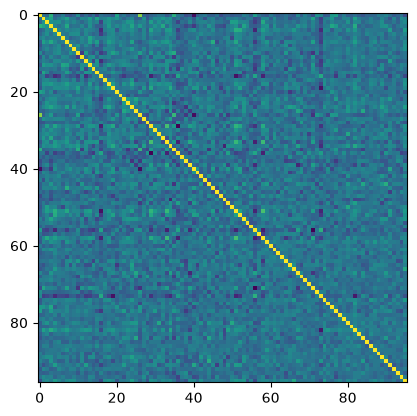

In [7]:
plt.imshow(val_cor)
plt.show()

# whitening

In [10]:
train_mu, train_cov, train_cor = get_stats(features['train'])

eye = torch.eye(train_cov.shape[0])
L = torch.linalg.cholesky(train_cov + 1e-5 * eye)
W = torch.linalg.inv(L).T

X = features['validation']
Xw = (X - train_mu) @ W

white_mu, white_cov, white_cor = get_stats(Xw)

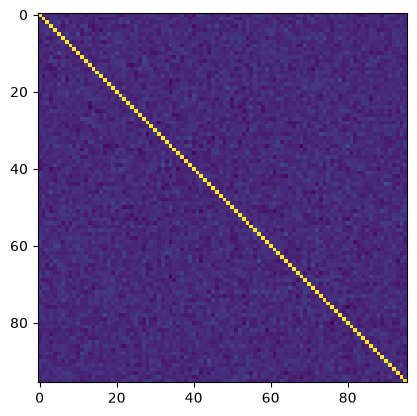

In [9]:
plt.imshow(white_cor)
plt.show()

In [19]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from mpl_toolkits.axes_grid1.inset_locator import inset_axes


def plot_corr_matrices(corr1, corr2, labels=None,
                       titles=("Matrix 1", "Matrix 2"),
                       cmap="RdBu_r",
                       bins=30):

    # ------------------------------------------------------------
    # 1. Get the ordering from seaborn's clustering
    # ------------------------------------------------------------
    def get_cluster_order(corr):
        # Temporary clustermap only to obtain the ordering
        g = sns.clustermap(
            corr,
            row_cluster=True,
            col_cluster=True,
            cmap=cmap,
            xticklabels=False,
            yticklabels=False,
        )

        order = g.dendrogram_row.reordered_ind
        plt.close(g.fig)

        return order

    order = get_cluster_order(corr1)
    order1 = order
    order2 = order

    # If both matrices have the same variables, you may want
    # exactly the same ordering for direct comparison.
    # In that case, use:
    #
    # order = get_cluster_order(corr1)
    # order1 = order2 = order

    corr1_ordered = np.asarray(corr1)[np.ix_(order1, order1)]
    corr2_ordered = np.asarray(corr2)[np.ix_(order2, order2)]

    if labels is not None:
        labels1 = np.asarray(labels)[order1]
        labels2 = np.asarray(labels)[order2]
    else:
        labels1 = labels2 = None

    # ------------------------------------------------------------
    # 2. Fixed color scale centered at zero
    # ------------------------------------------------------------
    norm = TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)

    # ------------------------------------------------------------
    # 3. Figure
    # ------------------------------------------------------------
    fig, axes = plt.subplots(
        1, 2,
        figsize=(14, 7),
        constrained_layout=True
    )

    matrices = [corr1_ordered, corr2_ordered]
    ordered_labels = [labels1, labels2]

    for ax, matrix, matrix_labels, title in zip(
        axes, matrices, ordered_labels, titles
    ):
        # Heatmap
        sns.heatmap(
            matrix,
            ax=ax,
            cmap=cmap,
            norm=norm,
            square=True,
            xticklabels=matrix_labels if matrix_labels is not None else False,
            yticklabels=matrix_labels if matrix_labels is not None else False,
            cbar=False,
        )

        ax.set_title(title)

        # --------------------------------------------------------
        # 4. Histogram of off-diagonal values
        #    placed in the upper-right corner
        # --------------------------------------------------------
        off_diag = matrix[~np.eye(matrix.shape[0], dtype=bool)]

        hist_ax = inset_axes(
            ax,
            width="28%",
            height="28%",
            loc="upper right",
            borderpad=1.0,
        )

        hist_ax.hist(
            off_diag,
            bins=bins,
            range=(-1, 1),
            density=True,
        )

        hist_ax.set_xlim(-1, 1)
        hist_ax.set_xticks([-1, 0, 1])
        hist_ax.tick_params(
            axis="both",
            labelsize=7,
            length=2,
        )

        hist_ax.axvline(0, linestyle="--", linewidth=0.8)

        # White background so the heatmap doesn't show through
        hist_ax.set_facecolor("white")

    # One shared colorbar
    sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])

    fig.colorbar(
        sm,
        ax=axes,
        shrink=0.75,
        label="Correlation",
    )

    return fig, axes

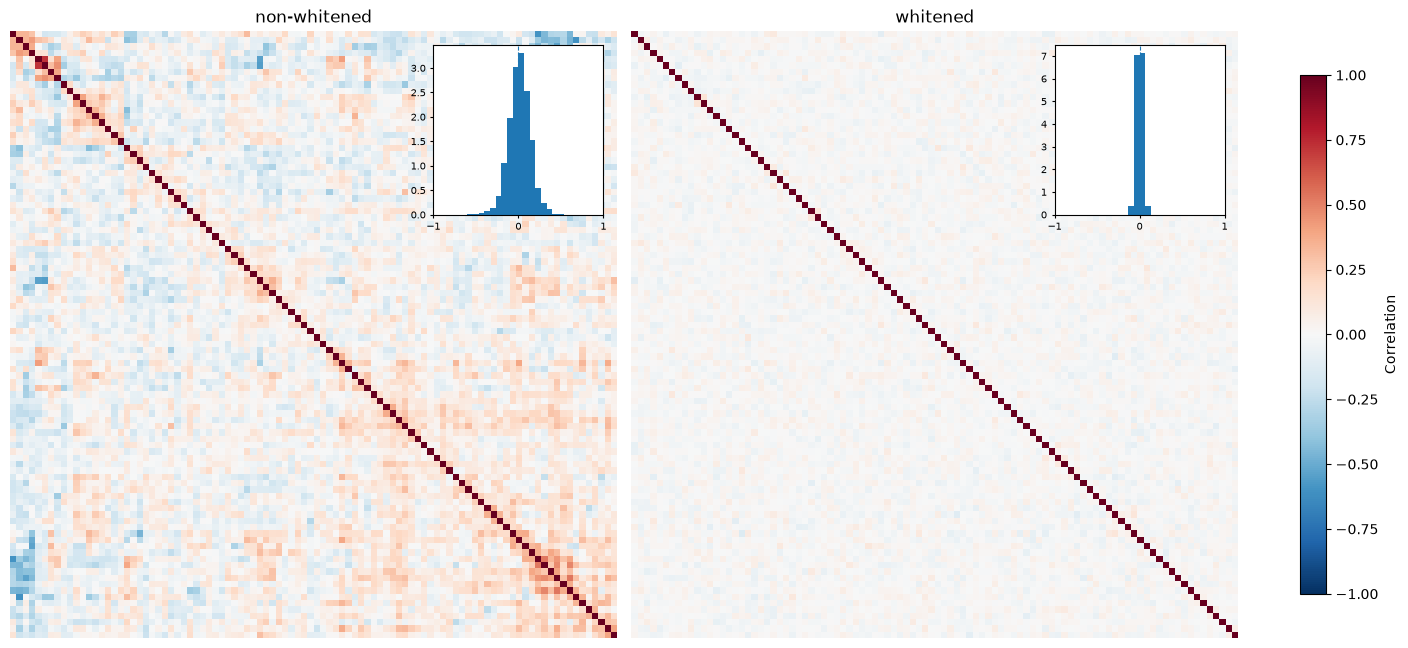

In [20]:
fig, axes = plot_corr_matrices(
    val_cor,
    white_cor,
    labels=None,
    titles=('non-whitened', 'whitened'),
)
plt.show()